In [4]:
# =============================================================
# PROJECT : NER + Relation Extraction -> Knowledge Graph
# STEP 1: Data loading + subword label alignment
# =============================================================
# WHAT THIS PROJECT DOES (read this first):
#
#   Raw text  ->  [NER model]  ->  entities (PERSON, ORG, LOC)
#             ->  [relation extraction]  ->  (subject, relation, object)
#             ->  [graph builder]  ->  a queryable knowledge graph
#
# Project 1 was SEQUENCE classification (one label per sentence).
# This is TOKEN classification (one label per WORD). That difference
# creates the single hardest concept in this project: label alignment.
#
# THE ALIGNMENT PROBLEM:
#   Your dataset labels WORDS:      ["Elon", "Musk", "founded", "SpaceX"]
#                                   [ B-PER,  I-PER,   O,        B-ORG ]
#   But the tokenizer makes SUBWORDS: ["elon", "mu", "##sk", "founded", "space", "##x"]
#   Now the labels don't line up. We must expand word-labels onto
#   subword-tokens, and mark the "continuation" pieces with -100
#   (PyTorch's ignore_index) so they contribute no loss.
#
# BIO TAGGING SCHEME:
#   B-PER = Beginning of a person entity
#   I-PER = Inside (continuation) of a person entity
#   O     = Outside any entity
#   This is how we encode multi-word entities in a per-token format.
# =============================================================

!pip install datasets transformers seqeval -q

# --- Colab compatibility patch (same torchvision issue as Project 1) ---
import datasets.formatting.torch_formatter as _tf
_tf.config.TORCHVISION_AVAILABLE = False
# -----------------------------------------------------------------------

import torch
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer

# -------------------------------------------------------------
# 1. Load CoNLL-2003 (the standard NER benchmark)
# -------------------------------------------------------------
# Namespaced path avoids the HfUriError we hit in Project 1.
# NOTE: conll2003 repos (eriktks/conll2003, conllpp, tner/conll2003) all
# ship the old loading-script format, which datasets no longer executes.
# Fix: HF auto-generates a parquet mirror of every dataset (script-based
# or not) on the "refs/convert/parquet" branch — load that directly.
dataset = load_dataset("eriktks/conll2003", revision="refs/convert/parquet")

print(dataset)
print(dataset["train"][0])
# Structure: {'tokens': [...words...], 'ner_tags': [...ints...], ...}

# -------------------------------------------------------------
# 2. Inspect the label scheme
# -------------------------------------------------------------
label_list = dataset["train"].features["ner_tags"].feature.names
print("Labels:", label_list)
# ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']

id2label = {i: l for i, l in enumerate(label_list)}
label2id = {l: i for i, l in enumerate(label_list)}
NUM_LABELS = len(label_list)
print("Num labels:", NUM_LABELS)

# See a real example decoded
ex = dataset["train"][0]
for tok, tag in zip(ex["tokens"], ex["ner_tags"]):
    print(f"{tok:15s} -> {id2label[tag]}")

# -------------------------------------------------------------
# 3. Tokenizer
# -------------------------------------------------------------
MODEL_NAME = "distilbert-base-cased"   # CASED matters for NER!
# Why cased? "Apple" (company) vs "apple" (fruit). Lowercasing
# destroys a huge signal for entity recognition.

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# -------------------------------------------------------------
# 4. THE CORE FUNCTION: align word-level labels to subword tokens
# -------------------------------------------------------------
def tokenize_and_align_labels(examples):
    tokenized = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True,   # tells HF our input is ALREADY word-split
        max_length=128,
        padding="max_length",
    )

    all_labels = []
    for i, word_labels in enumerate(examples["ner_tags"]):
        # word_ids() maps each subword token back to its original word index
        # e.g. ["[CLS]","elon","mu","##sk",...] -> [None, 0, 1, 1, ...]
        word_ids = tokenized.word_ids(batch_index=i)

        label_ids = []
        previous_word_id = None
        for word_id in word_ids:
            if word_id is None:
                # Special tokens ([CLS], [SEP], padding) -> ignored in loss
                label_ids.append(-100)
            elif word_id != previous_word_id:
                # FIRST subword of a word -> gets the real label
                label_ids.append(word_labels[word_id])
            else:
                # CONTINUATION subword (e.g. "##sk") -> ignored in loss
                label_ids.append(-100)
            previous_word_id = word_id

        all_labels.append(label_ids)

    tokenized["labels"] = all_labels
    return tokenized

# Apply to all splits
tokenized_ds = dataset.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=dataset["train"].column_names,
)

print(tokenized_ds)

# -------------------------------------------------------------
# 5. VERIFY the alignment worked (do not skip this)
# -------------------------------------------------------------
sample = tokenized_ds["train"][0]
tokens = tokenizer.convert_ids_to_tokens(sample["input_ids"])

print("\n--- Alignment check ---")
for tok, lab in list(zip(tokens, sample["labels"]))[:25]:
    lab_str = "IGNORED" if lab == -100 else id2label[lab]
    print(f"{tok:15s} -> {lab_str}")

# =============================================================
# CHECKPOINT - answer these before moving on:
# 1. Why do continuation subwords get -100 instead of the same label?
# 2. What would break if we used an UNCASED model here?
# 3. In BIO tagging, why do we need both B- and I- prefixes?
#    (Hint: "New York Los Angeles" - how do you know where one
#     location ends and the next begins without B-?)
# =============================================================

conll2003/train/0000.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

conll2003/train/0000.parquet: downloading bytes:           |  0.00B            

0000.parquet:   0%|          | 0.00/312k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/283k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

...

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

Map:   0%|          | 0/14041 [00:00<?, ? examples/s]

Map:   0%|          | 0/3250 [00:00<?, ? examples/s]

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 3453
    })
})

--- Alignment check ---
[CLS]           -> IGNORED
EU              -> B-ORG
rejects         -> O
German          -> B-MISC
call            -> O
to              -> O
boycott         -> O
British         -> B-MISC
la              -> O
##mb            -> IGNORED
.               -> O
[SEP]           -> IGNORED
[PAD]           -> IGNORED
[PAD]           -> IGNORED
[PAD]           -> IGNORED
[PAD]           -> IGNORED
[PAD]           -> IGNORED
[PAD]           -> IGNORED
[PAD]           -> IGNORED
[PAD]           -> IGNORED
[PAD]           -> IGNORED
[PAD]           -> IGNORED
[PAD]    

In [5]:
# =============================================================
# STEP 2: Train the NER model + evaluate properly
# =============================================================
# CONCEPT: Token classification = a linear classifier on top of
# every token's contextual embedding. Same DistilBERT backbone
# as Project 1, but instead of pooling to ONE vector and
# classifying once, we classify EVERY token position.
#
#   Project 1:  [CLS] w1 w2 w3  ->  pool  ->  1 label
#   Project 3:  [CLS] w1 w2 w3  ->  no pool ->  1 label PER TOKEN
#
# WHY seqeval AND NOT PLAIN ACCURACY:
#   ~85% of NER tokens are "O" (not an entity). A model that
#   predicts "O" for everything scores ~85% token accuracy while
#   being completely useless. seqeval scores ENTITY-LEVEL
#   precision/recall/F1: it only counts an entity correct if the
#   FULL span AND the type both match. That's the honest metric.
# =============================================================

import numpy as np
import torch
from transformers import (
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
)
from seqeval.metrics import precision_score, recall_score, f1_score, classification_report

# -------------------------------------------------------------
# 1. Load the model with a token-classification head
# -------------------------------------------------------------
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,   # baked into the model so inference returns readable tags
    label2id=label2id,
)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")

# -------------------------------------------------------------
# 2. Metrics function (entity-level, via seqeval)
# -------------------------------------------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    # Strip out the -100 positions (special tokens + subword continuations)
    # and convert integer ids back to BIO strings for seqeval.
    true_labels, true_preds = [], []
    for pred_row, label_row in zip(predictions, labels):
        row_labels, row_preds = [], []
        for p, l in zip(pred_row, label_row):
            if l != -100:
                row_labels.append(id2label[l])
                row_preds.append(id2label[p])
        true_labels.append(row_labels)
        true_preds.append(row_preds)

    return {
        "precision": precision_score(true_labels, true_preds),
        "recall": recall_score(true_labels, true_preds),
        "f1": f1_score(true_labels, true_preds),
    }

# -------------------------------------------------------------
# 3. Train
# -------------------------------------------------------------
data_collator = DataCollatorForTokenClassification(tokenizer)

args = TrainingArguments(
    output_dir="./ner_conll2003",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

# -------------------------------------------------------------
# 4. Final evaluation on the TEST set
# -------------------------------------------------------------
test_results = trainer.evaluate(tokenized_ds["test"])
print("\n--- Test set results ---")
print(test_results)

# -------------------------------------------------------------
# 5. Per-entity-type breakdown (which types are hardest?)
# -------------------------------------------------------------
predictions, labels, _ = trainer.predict(tokenized_ds["test"])
preds = np.argmax(predictions, axis=-1)

true_labels, true_preds = [], []
for pred_row, label_row in zip(preds, labels):
    row_labels, row_preds = [], []
    for p, l in zip(pred_row, label_row):
        if l != -100:
            row_labels.append(id2label[l])
            row_preds.append(id2label[p])
    true_labels.append(row_labels)
    true_preds.append(row_preds)

print("\n--- Per-entity-type report ---")
print(classification_report(true_labels, true_preds))

# Keep these for the README / charts later
ner_test_f1 = test_results["eval_f1"]
ner_test_precision = test_results["eval_precision"]
ner_test_recall = test_results["eval_recall"]

# -------------------------------------------------------------
# 6. Save the model so later steps can load it
# -------------------------------------------------------------
trainer.save_model("./ner_model_final")
tokenizer.save_pretrained("./ner_model_final")
print("\nSaved model to ./ner_model_final")

model.safetensors: reconstructing file:   0%|          |  0.00B /  263MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForTokenClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model parameters: 65,197,833


...

Training Loss,Validation Loss,Epoch,Precision,Recall,F1
0.027718,0.104734,3,0.875369,0.893515,0.884349



--- Test set results ---
{'eval_loss': 0.10473434627056122, 'eval_precision': 0.8753688595729908, 'eval_recall': 0.8935152374202693, 'eval_f1': 0.8843489697501097}



--- Per-entity-type report ---
              precision    recall  f1-score   support

         LOC       0.91      0.91      0.91      1666
        MISC       0.71      0.79      0.75       702
         ORG       0.84      0.87      0.86      1661
         PER       0.95      0.95      0.95      1615

   micro avg       0.88      0.89      0.88      5644
   macro avg       0.85      0.88      0.87      5644
weighted avg       0.88      0.89      0.89      5644



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Saved model to ./ner_model_final


In [6]:
# =============================================================
# STEP 3: Inference — extract entities from raw text
# =============================================================
# CONCEPT: The model outputs a BIO tag per subword token. To get
# usable entities we must:
#   1. Merge subwords back into words
#   2. Merge B-X followed by I-X into ONE entity span
# The `aggregation_strategy="simple"` flag in the HF pipeline
# does step 2 for us, but we also write it manually below so you
# understand what it's actually doing.
# =============================================================

from transformers import pipeline, AutoModelForTokenClassification, AutoTokenizer
import torch

# -------------------------------------------------------------
# 1. Load your fine-tuned model
# -------------------------------------------------------------
ner_model = AutoModelForTokenClassification.from_pretrained("./ner_model_final")
ner_tokenizer = AutoTokenizer.from_pretrained("./ner_model_final")

device = 0 if torch.cuda.is_available() else -1

ner_pipeline = pipeline(
    "token-classification",
    model=ner_model,
    tokenizer=ner_tokenizer,
    aggregation_strategy="simple",   # merges B-X + I-X into single spans
    device=device,
)

# -------------------------------------------------------------
# 2. Test it on real sentences
# -------------------------------------------------------------
test_sentences = [
    "Elon Musk founded SpaceX in California and later acquired Twitter.",
    "Satya Nadella is the CEO of Microsoft, headquartered in Redmond.",
    "Google acquired DeepMind, a research lab based in London.",
    "Imran Khan served as the Prime Minister of Pakistan.",
    "Apple announced a new office in Islamabad last year.",
]

for sent in test_sentences:
    print(f"\nSentence: {sent}")
    entities = ner_pipeline(sent)
    for e in entities:
        print(f"   {e['word']:20s} {e['entity_group']:6s} (conf: {e['score']:.3f})")

# -------------------------------------------------------------
# 3. A clean wrapper we'll reuse in the relation-extraction step
# -------------------------------------------------------------
def extract_entities(text, min_score=0.80):
    """
    Returns a list of dicts:
      [{'text': 'Elon Musk', 'type': 'PER', 'start': 0, 'end': 9}, ...]
    Filters out low-confidence predictions.
    """
    raw = ner_pipeline(text)
    entities = []
    for e in raw:
        if e["score"] < min_score:
            continue
        entities.append({
            "text": e["word"].strip(),
            "type": e["entity_group"],
            "start": e["start"],
            "end": e["end"],
            "score": float(e["score"]),
        })
    return entities

# Sanity check
print("\n--- extract_entities() output ---")
print(extract_entities("Elon Musk founded SpaceX in California."))

# -------------------------------------------------------------
# 4. MANUAL BIO merging (for understanding — not used downstream)
# -------------------------------------------------------------
# This shows what aggregation_strategy="simple" does internally.
def manual_bio_merge(text):
    raw = ner_pipeline.tokenizer(text, return_offsets_mapping=True, truncation=True)
    # Run model without aggregation to see raw per-token tags
    raw_pipe = pipeline("token-classification", model=ner_model,
                        tokenizer=ner_tokenizer, device=device)  # no aggregation
    tagged = raw_pipe(text)

    entities, current = [], None
    for t in tagged:
        tag = t["entity"]
        if tag.startswith("B-"):
            if current:
                entities.append(current)
            current = {"text": t["word"], "type": tag[2:]}
        elif tag.startswith("I-") and current and current["type"] == tag[2:]:
            # continuation — append (handling ## subword pieces)
            piece = t["word"]
            current["text"] += piece[2:] if piece.startswith("##") else " " + piece
        else:
            if current:
                entities.append(current)
            current = None
    if current:
        entities.append(current)
    return entities

print("\n--- manual BIO merge (same result, done by hand) ---")
print(manual_bio_merge("Elon Musk founded SpaceX in California."))

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]


Sentence: Elon Musk founded SpaceX in California and later acquired Twitter.
   Elon Mu              PER    (conf: 0.688)
   ##sk                 ORG    (conf: 0.722)
   SpaceX               ORG    (conf: 0.986)
   California           LOC    (conf: 0.996)
   Twitter              ORG    (conf: 0.977)

Sentence: Satya Nadella is the CEO of Microsoft, headquartered in Redmond.
   Sa                   PER    (conf: 0.995)
   ##tya Nadell         PER    (conf: 0.679)
   Microsoft            ORG    (conf: 0.996)
   Redmond              LOC    (conf: 0.942)

Sentence: Google acquired DeepMind, a research lab based in London.
   Google               ORG    (conf: 0.992)
   DeepMind             ORG    (conf: 0.986)
   London               LOC    (conf: 0.997)

Sentence: Imran Khan served as the Prime Minister of Pakistan.
   Imran Khan           PER    (conf: 0.824)
   Pakistan             LOC    (conf: 0.996)

Sentence: Apple announced a new office in Islamabad last year.
   Apple           

In [7]:
# =============================================================
# STEP 4: Relation Extraction
# =============================================================
# THE PROBLEM: NER gives you NODES (entities). A knowledge graph
# needs EDGES too — how entities relate.
#
#   "Elon Musk founded SpaceX"
#   NER gives:      [Elon Musk: PER]  [SpaceX: ORG]
#   We still need:  (Elon Musk) --founded--> (SpaceX)
#
# APPROACH: dependency-parse-based Subject-Verb-Object extraction.
# A dependency parse tells us the grammatical structure:
#
#        founded  (ROOT, verb)
#        /      \
#   nsubj        dobj
#   Musk         SpaceX
#
# We walk the parse tree, find the verb, find its subject (nsubj)
# and object (dobj/pobj), and check that BOTH map onto entities
# our NER model found. That last check is what keeps the graph
# clean — we only keep relations between real entities.
#
# WHY RULE-BASED AND NOT A TRAINED MODEL:
#   Trained relation extractors need labeled relation data (rare
#   and expensive). Dependency rules get you a working graph
#   immediately and are fully interpretable — you can always see
#   WHY a triple was extracted. The trade-off is recall: rules
#   miss relations phrased in unusual ways.
# =============================================================

!pip install spacy -q
!python -m spacy download en_core_web_sm -q

import spacy
from collections import Counter

nlp = spacy.load("en_core_web_sm")

# -------------------------------------------------------------
# 1. Inspect a dependency parse (build intuition first)
# -------------------------------------------------------------
doc = nlp("Elon Musk founded SpaceX in California.")
print("--- Dependency parse ---")
for token in doc:
    print(f"{token.text:12s} POS={token.pos_:6s} DEP={token.dep_:10s} HEAD={token.head.text}")

# -------------------------------------------------------------
# 2. Map a character span to an entity (links spaCy tokens to NER output)
# -------------------------------------------------------------
def find_entity_for_span(entities, start_char, end_char):
    """Return the NER entity overlapping this character range, if any."""
    for ent in entities:
        if not (end_char <= ent["start"] or start_char >= ent["end"]):
            return ent
    return None

# -------------------------------------------------------------
# 3. Core relation extractor
# -------------------------------------------------------------
def extract_relations(text, entities=None):
    """
    Returns a list of triples:
      [{'subject': 'Elon Musk', 'subject_type': 'PER',
        'relation': 'founded',
        'object': 'SpaceX',    'object_type': 'ORG'}, ...]
    """
    if entities is None:
        entities = extract_entities(text)   # from Step 3

    doc = nlp(text)
    triples = []

    for token in doc:
        # We anchor on VERBS — they're the relations.
        if token.pos_ not in ("VERB", "AUX"):
            continue

        subjects, objects = [], []

        for child in token.children:
            # --- subject side ---
            if child.dep_ in ("nsubj", "nsubjpass"):
                subjects.append(child)
            # --- direct object ---
            elif child.dep_ in ("dobj", "attr", "oprd"):
                objects.append(child)
            # --- prepositional object: "founded [in] California" ---
            elif child.dep_ == "prep":
                for grandchild in child.children:
                    if grandchild.dep_ == "pobj":
                        objects.append(grandchild)
            # --- "is the CEO of Microsoft" style ---
            elif child.dep_ == "acomp":
                objects.append(child)

        for subj in subjects:
            # Expand to the full noun phrase (so we catch "Elon Musk", not just "Musk")
            subj_span = doc[subj.left_edge.i : subj.right_edge.i + 1]
            subj_ent = find_entity_for_span(entities, subj_span.start_char, subj_span.end_char)
            if subj_ent is None:
                continue

            for obj in objects:
                obj_span = doc[obj.left_edge.i : obj.right_edge.i + 1]
                obj_ent = find_entity_for_span(entities, obj_span.start_char, obj_span.end_char)
                if obj_ent is None:
                    continue
                if subj_ent["text"] == obj_ent["text"]:
                    continue  # skip self-loops

                # Build a readable relation label from the verb (+ preposition)
                relation = token.lemma_
                for child in token.children:
                    if child.dep_ == "prep" and obj in child.subtree:
                        relation = f"{token.lemma_} {child.text}"
                        break

                triples.append({
                    "subject": subj_ent["text"],
                    "subject_type": subj_ent["type"],
                    "relation": relation,
                    "object": obj_ent["text"],
                    "object_type": obj_ent["type"],
                })

    return triples

# -------------------------------------------------------------
# 4. Test on sentences
# -------------------------------------------------------------
test_texts = [
    "Elon Musk founded SpaceX in California.",
    "Satya Nadella leads Microsoft from Redmond.",
    "Google acquired DeepMind, a research lab based in London.",
    "Imran Khan governed Pakistan for several years.",
    "Sundar Pichai joined Google in 2004 and now runs Alphabet.",
]

print("\n--- Extracted relations ---")
for text in test_texts:
    ents = extract_entities(text)
    rels = extract_relations(text, ents)
    print(f"\n{text}")
    print(f"  Entities: {[(e['text'], e['type']) for e in ents]}")
    for r in rels:
        print(f"  ({r['subject']}) --[{r['relation']}]--> ({r['object']})")

# -------------------------------------------------------------
# 5. Run the full pipeline over a document (many sentences)
# -------------------------------------------------------------
def process_document(text):
    """Split into sentences, run NER + relation extraction on each,
    return all entities and all triples."""
    doc = nlp(text)
    all_entities, all_triples = [], []

    for sent in doc.sents:
        sent_text = sent.text.strip()
        if len(sent_text) < 5:
            continue
        ents = extract_entities(sent_text)
        rels = extract_relations(sent_text, ents)
        all_entities.extend(ents)
        all_triples.extend(rels)

    return all_entities, all_triples

# Sample document to build the graph from
SAMPLE_DOC = """
Elon Musk founded SpaceX in California in 2002. He also leads Tesla,
an electric vehicle company based in Austin. Musk acquired Twitter in 2022.

Satya Nadella is the chief executive of Microsoft. Microsoft is headquartered
in Redmond, Washington. Nadella joined Microsoft in 1992.

Google acquired DeepMind, an artificial intelligence lab located in London.
Sundar Pichai runs Google and also leads Alphabet from Mountain View.
DeepMind was founded by Demis Hassabis in London.

Jeff Bezos founded Amazon in Seattle. Amazon acquired Whole Foods in 2017.
Andy Jassy now leads Amazon Web Services.
"""

entities, triples = process_document(SAMPLE_DOC)

print(f"\n\n--- Document processed ---")
print(f"Total entities found: {len(entities)}")
print(f"Total relations found: {len(triples)}")
print(f"\nEntity type distribution: {Counter(e['type'] for e in entities)}")
print(f"Most common relations: {Counter(t['relation'] for t in triples).most_common(10)}")

print("\n--- All triples ---")
for t in triples:
    print(f"  ({t['subject']}) --[{t['relation']}]--> ({t['object']})")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 87.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


--- Dependency parse ---
Elon         POS=PROPN  DEP=compound   HEAD=Musk
Musk         POS=PROPN  DEP=nsubj      HEAD=founded
founded      POS=VERB   DEP=ROOT       HEAD=founded
SpaceX       POS=PROPN  DEP=dobj       HEAD=founded
in           POS=ADP    DEP=prep       HEAD=founded
California   POS=PROPN  DEP=pobj       HEAD=in
.            POS=PUNCT  DEP=punct      HEAD=founded

--- Extracted relations ---

Elon Musk founded SpaceX in California.
  Entities: [('Elon Mu', 'PER'), ('SpaceX', 'ORG'), ('California', 'LOC')]
  (Elon Mu) --[found]--> (SpaceX)
  (Elon Mu) --[found in]--> (California)

Satya Nadella leads Microsoft from Redmond.
  Entities: [('Sa', 'PER'), ('Microsoft', 'ORG'), ('Redmond', 'ORG')]
  (Sa) --[lead]--> (Microsoft)
  (Sa) --[lead from]--> (Redmond)

Google acquired DeepMind, a research lab based in London.
  Entities: [('Google', 'ORG'), ('DeepMind', 'ORG'), ('London', 'LOC')]
  (Google) --[acquire]--> (DeepMind)

Imran Khan governed Pakistan for several years.
  

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 81.8 MB/s eta 0:00:00
Graph built: 22 nodes, 10 edges
Node types: Counter({'ORG': 11, 'LOC': 6, 'PER': 5})

=== Top 5 most connected entities ===
  Microsoft                 (ORG  )  connections: 2
  Google                    (ORG  )  connections: 2
  DeepMind                  (ORG  )  connections: 2
  Jeff Bezos                (PER  )  connections: 2
  Amazon                    (ORG  )  connections: 2

=== All ORG entities ===
  SpaceX, Tesla, Musk, Twitter, Microsoft, Google, DeepMind, Alphabet, Amazon, Whole Foods, Amazon Web Services

=== All PER entities ===
  Sa, Sundar Picha, Demis Hassabis, Jeff Bezos, Andy Jass
'Elon Musk' not in graph.

=== Microsoft (ORG) ===
  Microsoft --[headquarter in]--> Redmond
  Sa --[be]--> Microsoft
One or both entities not in graph.


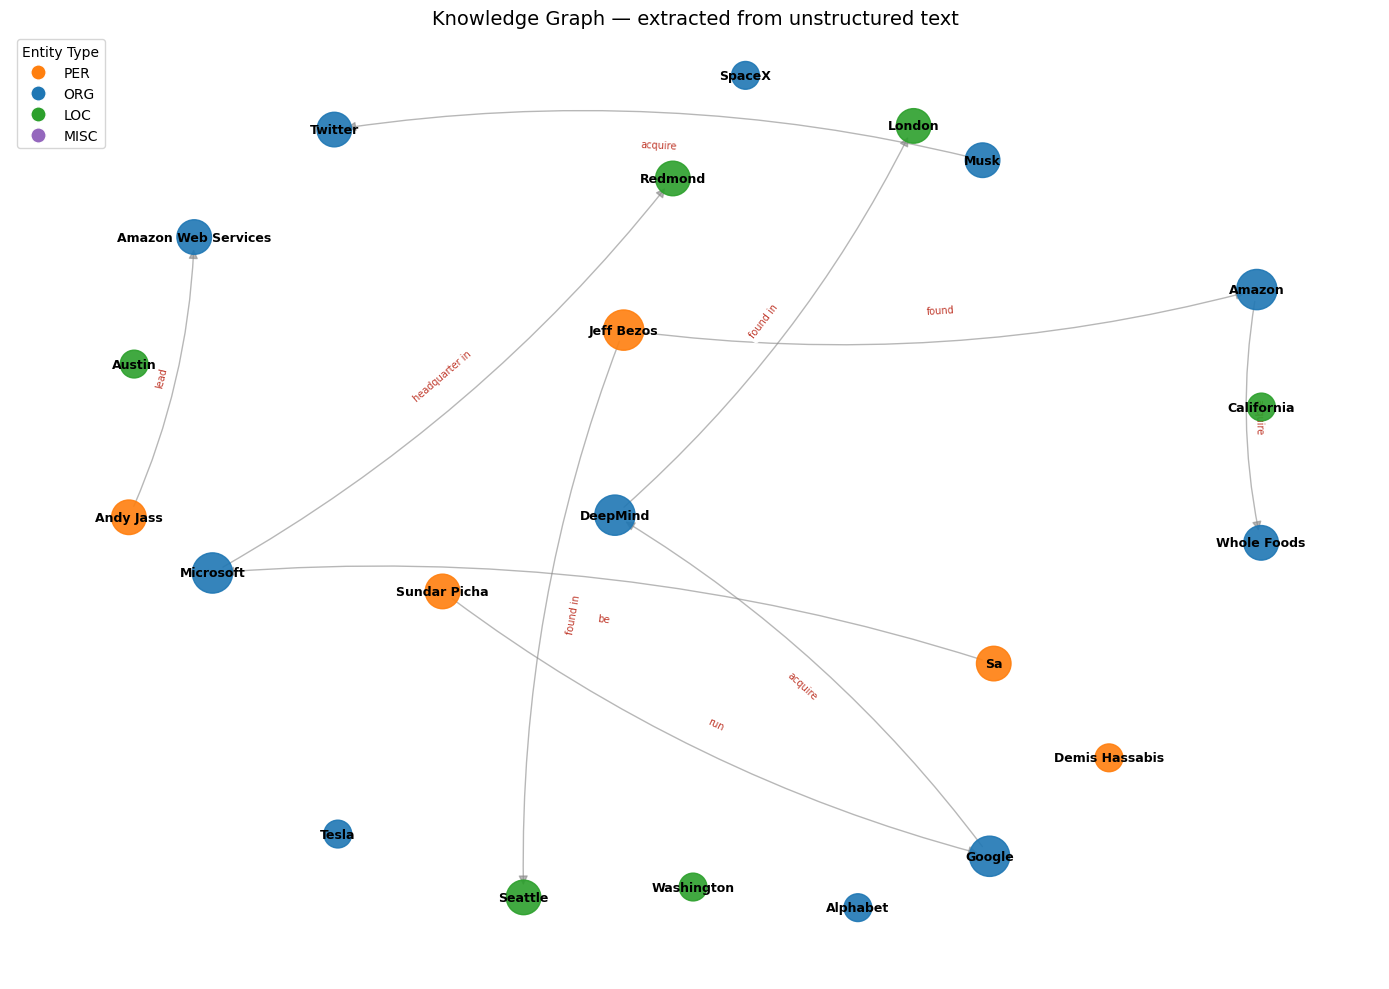

Saved knowledge_graph.png
Saved knowledge_graph.html — download it and open in a browser.
Saved knowledge_graph_triples.json (10 triples)
Saved knowledge_graph.graphml


In [8]:
# =============================================================
# STEP 5: Build, query, and visualize the Knowledge Graph
# =============================================================
# CONCEPT: A knowledge graph is a directed, labeled multigraph.
#   NODES = entities (typed: PER / ORG / LOC / MISC)
#   EDGES = relations (labeled with the verb)
#
# Once it's a graph, you get graph algorithms for free:
#   - degree centrality -> who/what is most connected?
#   - shortest path     -> how are two entities linked?
#   - neighbors         -> everything known about one entity
# That's the payoff: unstructured text becomes queryable structure.
# =============================================================

!pip install networkx pyvis -q

import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

# -------------------------------------------------------------
# 1. Build the graph from triples
# -------------------------------------------------------------
def build_knowledge_graph(entities, triples):
    G = nx.MultiDiGraph()   # MultiDiGraph = directed, allows multiple edges per pair

    # Add nodes with their entity type as an attribute
    entity_types = {}
    for e in entities:
        entity_types[e["text"]] = e["type"]

    for name, etype in entity_types.items():
        G.add_node(name, entity_type=etype)

    # Add edges
    for t in triples:
        G.add_edge(t["subject"], t["object"], relation=t["relation"])

    return G

G = build_knowledge_graph(entities, triples)

print(f"Graph built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Node types: {Counter(nx.get_node_attributes(G, 'entity_type').values())}")

# -------------------------------------------------------------
# 2. QUERY THE GRAPH — this is the actual value of the project
# -------------------------------------------------------------
def what_do_we_know_about(G, entity):
    """All outgoing and incoming relations for one entity."""
    if entity not in G:
        print(f"'{entity}' not in graph.")
        return
    print(f"\n=== {entity} ({G.nodes[entity].get('entity_type', '?')}) ===")
    for _, target, data in G.out_edges(entity, data=True):
        print(f"  {entity} --[{data['relation']}]--> {target}")
    for source, _, data in G.in_edges(entity, data=True):
        print(f"  {source} --[{data['relation']}]--> {entity}")

def most_connected_entities(G, top_n=5):
    """Degree centrality — the hubs of the graph."""
    degrees = dict(G.degree())
    ranked = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:top_n]
    print(f"\n=== Top {top_n} most connected entities ===")
    for name, deg in ranked:
        etype = G.nodes[name].get("entity_type", "?")
        print(f"  {name:25s} ({etype:5s})  connections: {deg}")
    return ranked

def find_connection(G, a, b):
    """Shortest path between two entities (ignoring edge direction)."""
    UG = G.to_undirected()
    if a not in UG or b not in UG:
        print("One or both entities not in graph.")
        return
    try:
        path = nx.shortest_path(UG, a, b)
        print(f"\n=== Connection: {a} <-> {b} ===")
        print("  " + " -> ".join(path))
        return path
    except nx.NetworkXNoPath:
        print(f"\nNo path between {a} and {b}.")

def entities_of_type(G, etype):
    """All entities of a given type."""
    result = [n for n, d in G.nodes(data=True) if d.get("entity_type") == etype]
    print(f"\n=== All {etype} entities ===")
    print("  " + ", ".join(result))
    return result

# Run the queries
most_connected_entities(G)
entities_of_type(G, "ORG")
entities_of_type(G, "PER")
what_do_we_know_about(G, "Elon Musk")
what_do_we_know_about(G, "Microsoft")
find_connection(G, "Elon Musk", "Microsoft")

# -------------------------------------------------------------
# 3. Static visualization (matplotlib) — goes in the README
# -------------------------------------------------------------
TYPE_COLORS = {
    "PER":  "#ff7f0e",
    "ORG":  "#1f77b4",
    "LOC":  "#2ca02c",
    "MISC": "#9467bd",
}

def draw_graph(G, filename="knowledge_graph.png"):
    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G, k=1.5, iterations=60, seed=42)

    node_colors = [
        TYPE_COLORS.get(G.nodes[n].get("entity_type"), "#999999")
        for n in G.nodes()
    ]
    node_sizes = [400 + 220 * G.degree(n) for n in G.nodes()]

    nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                           node_size=node_sizes, alpha=0.9)
    nx.draw_networkx_edges(G, pos, edge_color="#888888",
                           arrows=True, arrowsize=14,
                           connectionstyle="arc3,rad=0.1", alpha=0.6)
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")

    edge_labels = {(u, v): d["relation"] for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                                 font_size=7, font_color="#c0392b")

    # Legend
    handles = [plt.Line2D([0], [0], marker='o', color='w', label=t,
                          markerfacecolor=c, markersize=11)
               for t, c in TYPE_COLORS.items()]
    plt.legend(handles=handles, loc="upper left", title="Entity Type")

    plt.title("Knowledge Graph — extracted from unstructured text", fontsize=14)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {filename}")

draw_graph(G)

# -------------------------------------------------------------
# 4. Interactive visualization (pyvis) — the impressive demo
# -------------------------------------------------------------
